# コンセンサスアルゴリズム

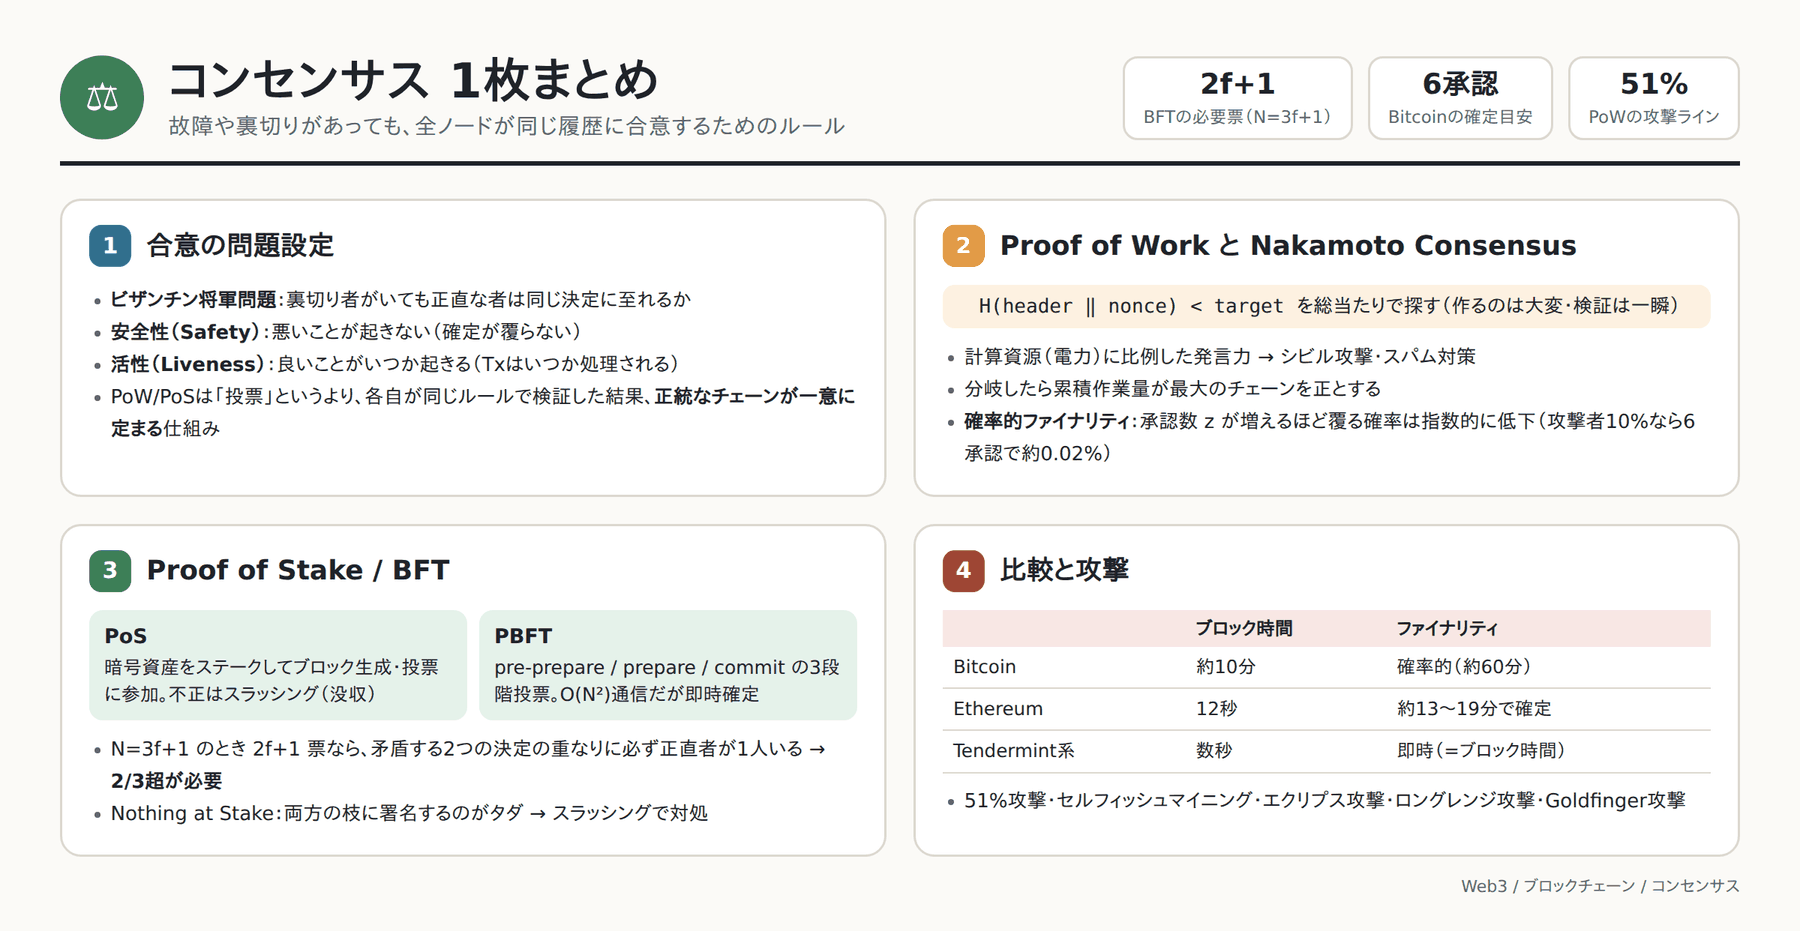

## 分散システムにおける合意

ブロックチェーンのノードは世界中に散らばっており、通信遅延があり、一部のノードは故障したり悪意を持っていたりする。その状況で、全ノードが同じ取引履歴（=操作の順序）に合意するための仕組みが **コンセンサスアルゴリズム（consensus algorithm）** である。

:::{card} ビザンチン将軍問題（Byzantine Generals Problem）

複数の将軍（ノード）が伝令（メッセージ）だけで連絡を取り合い、攻撃か撤退かを決める。一部の将軍は裏切り者で、矛盾したメッセージを送るかもしれない。このとき、忠実な将軍たちが全員同じ決定に到達できるか、という問題（Lamport, Shostak & Pease, 1982）。

裏切り者がいても正しく合意できる性質を **ビザンチン耐性（Byzantine Fault Tolerance, BFT）** という。
:::

合意アルゴリズムに求められる性質は、大きく2つに分けられる。

| 性質 | 意味 | ブロックチェーンでの例 |
| --- | --- | --- |
| 安全性（Safety） | 悪いことが起きない | 確定した取引が覆らない、二重支払いが起きない |
| 活性（Liveness） | 良いことがいつかは起きる | 正当な取引はいつか必ずブロックに取り込まれる |

ネットワークが分断されうる状況では、安全性と活性を同時に完全には満たせない（FLP不可能性、CAP定理）。どちらを優先するかでアルゴリズムの性格が分かれる。

:::{note}
PoWやPoSは「投票で皆の意見をまとめる」というより、各ノードが同じルールで独立に検証した結果、**世界で1つの正統なチェーンが自然に定まる**ようにするためのルールと捉えるとわかりやすい。
:::

## Proof of Work（PoW）

### 仕組み

**Proof of Work（作業証明）** は、ブロックを作る権利を計算競争で決める方式。

マイナーは、ブロックヘッダーのハッシュ値が **難易度ターゲット（difficulty target）** 未満になるような nonce を探す。

$$
\text{SHA256}(\text{SHA256}(\text{header}(\text{nonce}))) < \text{target}
$$

ハッシュ関数の出力は予測できないので、nonceを1つずつ変えて試すしかない。計算問題を解くというより、当たりが出るまでくじを引き続けるイメージで、計算資源を多く投入するほど1秒あたりに多くのくじを引ける。

一方、見つかったnonceが条件を満たすかの検証はハッシュを1回計算するだけで済む。この「作るのは大変だが検証は簡単」という非対称性がPoWの本質。

In [1]:
import hashlib
import time


def mine(header: str, difficulty_bits: int, max_nonce: int = 10**8):
    """ハッシュ値の先頭 difficulty_bits ビットが0になるnonceを探す"""
    target = 2 ** (256 - difficulty_bits)
    for nonce in range(max_nonce):
        digest = hashlib.sha256(hashlib.sha256(f"{header}{nonce}".encode()).digest()).hexdigest()
        if int(digest, 16) < target:
            return nonce, digest
    return None, None


for bits in [8, 12, 16, 20]:
    start = time.perf_counter()
    nonce, digest = mine("prev_hash|merkle_root|timestamp|", bits)
    elapsed = time.perf_counter() - start
    print(f"{bits:2d} bit: nonce={nonce:>8,d} 試行回数の期待値={2**bits:>9,d} 時間={elapsed:.3f}s  {digest[:16]}...")

 8 bit: nonce=     106 試行回数の期待値=      256 時間=0.000s  00d58402d26479ed...
12 bit: nonce=   3,340 試行回数の期待値=    4,096 時間=0.002s  000db62a0eea814d...
16 bit: nonce= 332,301 試行回数の期待値=   65,536 時間=0.164s  00005bdecba48528...


20 bit: nonce=1,180,691 試行回数の期待値=1,048,576 時間=0.589s  000009954e9a656e...


難易度が1ビット上がるごとに、必要な試行回数の期待値は2倍になる。

### なぜ計算コストを課すのか

- **シビル攻撃対策**：IDを大量に作るのはタダなので、「1ノード1票」では偽アカウントを量産した者が勝ってしまう。PoWは「1CPU 1票」、つまり現実の物理資源（電力・計算機）に比例した発言力にする
- **スパム対策**：無効なブロックを大量に流すことを抑止する
- **価値の裏付け**：報酬として発行される通貨に、生産コストという意味での価値を与える

### 難易度調整

Bitcoinでは2,016ブロック（約2週間）ごとに難易度ターゲットを調整し、ブロック生成間隔が平均10分になるようにしている。

$$
\text{new target} = \text{old target} \times \frac{\text{直近2016ブロックの所要時間}}{20160\text{分}}
$$

- マイナーが急増してブロック生成が速くなりすぎると、チェーンの分岐が頻発する → 難易度を上げる
- マイナーが急減すると、ブロックがいつまでもできずに取引が処理されない → 難易度を下げる

急激な変化を避けるため、1回の調整幅は1/4倍〜4倍に制限されている。

## Nakamoto Consensus

### 最長チェーンルール

マイナーが偶然ほぼ同時にブロックを見つけたり、伝播に遅延があったりすると、チェーンが一時的に分岐（fork）する。Bitcoinでは **最も多くの累積作業量を持つチェーン（俗に最長チェーン）を正統とする** ルールで分岐を解消する。分岐のどちらかに次のブロックが先に繋がった時点で、多くのノードがそちらに乗り換え、もう片方のブロックは捨てられる（stale block / orphan block）。

```mermaid
flowchart LR
    A[Block A] --> B[Block B] --> C[Block C] --> D[Block D] --> E[Block E]
    B --> C2["Block C'"]
    style C2 stroke-dasharray: 5 5
```

マイナーにとっても、正統なチェーンの先端にブロックを繋がないと報酬が無効になるため、最長チェーンに乗ることが合理的になる。

### 確率的ファイナリティ

Nakamoto Consensusでは、ブロックがいつ「確定」したと言えるかが明確でない。後からより長いチェーンが現れれば、既存のブロックが覆る可能性が常に残る。ただし、上に積まれたブロック数（承認数、confirmations）が増えるほど、覆る確率は指数的に小さくなる。これを **確率的ファイナリティ（probabilistic finality）** と呼ぶ。

Nakamotoの論文では、全ハッシュレートの割合 $q$ を持つ攻撃者が、$z$ ブロック遅れから正直なチェーンに追いつく確率を次のように計算している。正直なマイナーの割合を $p = 1-q$ とすると、ギャンブラーの破産問題より、$z$ ブロックの差を逆転できる確率は

$$
q_z = \begin{cases} 1 & (p \le q) \\ (q/p)^z & (p > q) \end{cases}
$$

正直なチェーンが $z$ ブロック進む間に攻撃者が進むブロック数を、期待値 $\lambda = z\frac{q}{p}$ のポアソン分布で近似すると、攻撃の成功確率は

$$
P = 1 - \sum_{k=0}^{z} \frac{\lambda^k e^{-\lambda}}{k!}\left(1 - (q/p)^{z-k}\right)
$$

となる。

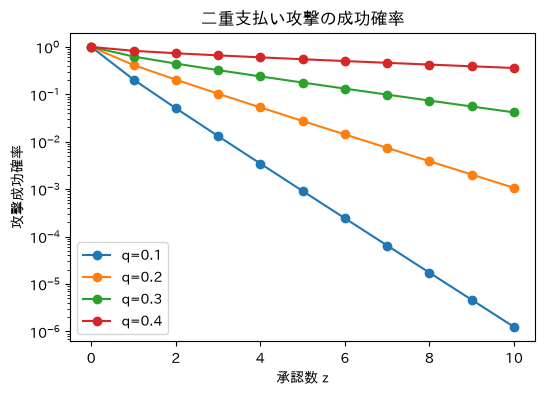

In [2]:
import math

import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401


def attacker_success(q: float, z: int) -> float:
    p = 1 - q
    lam = z * q / p
    s = 1.0
    for k in range(z + 1):
        poisson = math.exp(-lam) * lam**k / math.factorial(k)
        s -= poisson * (1 - (q / p) ** (z - k))
    return s


zs = range(0, 11)
fig, ax = plt.subplots(figsize=(6, 4))
for q in [0.1, 0.2, 0.3, 0.4]:
    ax.plot(zs, [attacker_success(q, z) for z in zs], marker="o", label=f"q={q}")
ax.set(yscale="log", xlabel="承認数 z", ylabel="攻撃成功確率", title="二重支払い攻撃の成功確率")
ax.legend()
plt.show()

攻撃者のハッシュレートが10%なら、6承認で成功確率は約0.02%まで下がる。Bitcoinで「6承認（約1時間）待てば安全」と言われる根拠はここにある。一方で攻撃者が過半数（$q \ge 0.5$）を持てば、いくら待っても確率は1になる。

## Proof of Stake（PoS）

### 仕組み

**Proof of Stake（保有証明）** では、計算資源の代わりに **暗号資産を預け入れる（ステークする）** ことで、ブロック生成や検証に参加する権利を得る。ステークした参加者（バリデータ）の中から、ブロック提案者や投票者がランダムに選ばれる。

- 正しく振る舞えば報酬が得られる
- 二重投票などの不正をすると、預けた資産が没収される（**スラッシング, slashing**）

という経済的インセンティブで正直な行動を促す。

### PoWとの比較

| 項目 | PoW | PoS |
| --- | --- | --- |
| 参加に必要な資源 | 計算資源（電力・専用ハードウェア） | ステークする暗号資産 |
| セキュリティの源泉 | 全体のハッシュレート | ステーク総量 |
| 攻撃コスト | ハッシュレートの過半数を確保する費用 | ステーク総量の1/3〜2/3を確保する費用。不正すればスラッシングで失う |
| コストの性質 | 外部資源（電力）を消費し続ける | システム内部の資産をロックする機会費用 |
| 環境負荷 | 大きい | 小さい |
| ファイナリティ | 確率的 | 決定論的なファイナリティを組み込める |
| 主な課題 | 電力消費、マイニングの寡占 | 富の集中、Nothing at Stake問題、ロングレンジ攻撃 |

:::{card} Nothing at Stake 問題

PoWでは、分岐したチェーンの両方でマイニングすると計算資源が分散して損をする。PoSでは署名するだけなのでコストがかからず、分岐した両方のチェーンに投票しておくのが合理的になってしまう。

Ethereumなどでは、矛盾する署名を行ったバリデータのステークを没収する（スラッシング）ことでこの問題に対処している。
:::

Ethereumの具体的なPoSの仕組みは [Proof of Stake（Ethereum）](../ethereum/proof_of_stake.ipynb) を参照。

## BFT系アルゴリズム

### PBFT

**PBFT（Practical Byzantine Fault Tolerance, Castro & Liskov 1999）** は、参加者が固定・既知の環境で、投票によって合意する古典的なアルゴリズム。

1. **Pre-prepare**：リーダーが提案を全ノードに送る
2. **Prepare**：各ノードが提案を受け取ったことを全ノードに送る
3. **Commit**：十分な数のPrepareを受け取ったノードが確定を全ノードに送る

全員が全員にメッセージを送るため通信量は $O(N^2)$ で、ノード数を増やしにくい。一方で、一度Commitされたブロックは覆らない **決定論的ファイナリティ（deterministic finality）** が得られる。

### なぜ2/3なのか

全ノード数を $N = 3f + 1$、そのうち最大 $f$ 台が悪意を持つ（ビザンチン）とする。

- 活性のため、$f$ 台が応答しなくても進める必要がある → 待てるのは最大 $N - f = 2f + 1$ 票まで
- 安全性のため、矛盾する2つの決定が両方とも $2f+1$ 票を集めることがあってはならない

2つの $2f+1$ 票の集合の重なりは少なくとも $2(2f+1) - (3f+1) = f+1$ 台で、そのうち少なくとも1台は正直なノードになる。正直なノードは矛盾する2つに投票しないので、矛盾した決定は起こらない。したがって、合意には **全体の2/3超の票（$2f+1$）** が必要になる。

PoS系のチェーン（Ethereum, Cosmos(Tendermint/CometBFT), Polkadotなど）の多くは、ファイナリティの部分にこの考え方を取り入れている。

### ブロック時間とファイナリティ時間

| 用語 | 意味 |
| --- | --- |
| ブロック時間（block time） | ブロックが生成される間隔。ブロックがチェーンに取り込まれても、分岐によって後で外れる可能性がある |
| ファイナリティ時間（time to finality） | ブロックが最終確定し、覆らなくなるまでの時間 |

| チェーン | ブロック時間 | ファイナリティ |
| --- | --- | --- |
| Bitcoin | 約10分 | 確率的（慣習的に6承認≒約60分） |
| Ethereum | 12秒 | 約2〜3エポック（約13〜19分）で決定論的に確定 |
| Tendermint系（Cosmos等） | 数秒 | ブロック時間 = ファイナリティ時間（即時確定） |

ファイナリティには全バリデータ間の投票と伝播が必要なため、ノード数や通信遅延という物理的な制約を受ける。ノード数を増やすほど分散性は高まるが、確定には時間がかかる。

## コンセンサスへの攻撃

| 攻撃 | 対象 | 概要 |
| --- | --- | --- |
| 51%攻撃 | コンセンサス | ハッシュレート（PoSならステーク）の過半数を握り、過去の取引を覆したり特定の取引を排除したりする |
| セルフィッシュマイニング | コンセンサス | 見つけたブロックを隠して掘り進め、都合のよいタイミングで一気に公開して他のマイナーの作業を無駄にする。過半数未満でも取り分を増やせる（Eyal & Sirer, 2014） |
| エクリプス攻撃 | ネットワーク | 標的ノードの接続先をすべて攻撃者のノードで占め、偽の情報を見せる |
| ロングレンジ攻撃 | PoS | 過去にステークしていた（現在は引き出し済みの）鍵を入手し、過去の時点から別のチェーンを作り直す |
| Goldfinger攻撃 | プロトコル外 | 空売りなどで価格下落から利益を得る立場を取ったうえでチェーンを攻撃する。「マイナーは報酬の価値を損なう攻撃をしない」という前提への反例 |